### HealthConnect Clinic – Data Analytics Project
### 1. Dataset Overview

The HealthConnect Appointment Dataset is a fictional and anonymised dataset containing appointment records from HealthConnect Clinic.

The dataset contains 5,000 appointment records and 18 variables covering patient demographics, appointment details, booking information, previous appointment history, reminder activity, clinic accessibility, waiting time and appointment outcomes.

The appointment_id serves as the primary key for each appointment, while patient_id is an anonymised patient identifier that may occur across multiple appointments.

The main variables relevant to the analysis include:

Patient demographics: gender, age, age_group
Appointment details: appointment_type, appointment_date, appointment_day, appointment_time
Booking behaviour: booking_lead_days, previous_appointments, previous_no_shows
Reminder information: reminder_sent, reminder_channel
Clinic accessibility and operations: distance_to_clinic_km, waiting_time_minutes
Appointment outcome: appointment_outcome

The analysis investigates patterns associated with appointment outcomes, particularly no-shows, across patient, appointment, booking, reminder and clinic-related factors. It also examines relationships among numerical variables, identifies unusual values, and explores stronger no-show patterns in greater detail. The aim is to provide evidence-based insights that may help HealthConnect Clinic understand factors associated with missed appointments and identify areas where appointment utilisation could be improved.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("HealthConnect_Appointment_Data.csv")
df.head(10)

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show
5,HC-00006,P-0523,Male,66,65+,Specialist Consultation,2/16/2026,4/14/2026,Tuesday,Morning,57,4,2,No,NaN,3.1,36.0,No-Show
6,HC-00007,P-0776,Male,58,55-64,Diagnostic Test,1/17/2025,2/16/2025,Sunday,Afternoon,30,4,1,Yes,WhatsApp,8.2,30.0,No-Show
7,HC-00008,P-0927,Female,28,25-34,Specialist Consultation,11/27/2025,1/16/2026,Friday,Afternoon,50,6,1,Yes,SMS,19.2,21.0,Attended
8,HC-00009,P-0388,Male,77,65+,Follow-up,3/9/2025,4/21/2025,Monday,Afternoon,43,3,0,Yes,SMS,10.1,27.0,No-Show
9,HC-00010,P-0371,Female,20,18-24,Follow-up,2/5/2025,2/21/2025,Friday,Afternoon,16,2,0,Yes,SMS,28.0,20.0,Attended


In [3]:
df.tail()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
4995,HC-04996,P-0007,Male,49,45-54,Diagnostic Test,3/29/2025,4/26/2025,Saturday,Morning,28,5,1,Yes,Email,4.4,35.0,No-Show
4996,HC-04997,P-1501,Female,52,45-54,Follow-up,12/14/2025,2/12/2026,Thursday,Evening,60,6,2,Yes,WhatsApp,12.6,24.0,Attended
4997,HC-04998,P-0315,Male,59,55-64,General Consultation,3/3/2026,3/24/2026,Tuesday,Afternoon,21,5,0,No,NaN,22.8,28.0,Attended
4998,HC-04999,P-1262,Male,47,45-54,General Consultation,12/3/2025,1/6/2026,Tuesday,Morning,34,4,1,No,NaN,12.5,16.0,Attended
4999,HC-05000,P-1793,Female,19,18-24,General Consultation,8/24/2025,9/30/2025,Tuesday,Morning,37,6,1,Yes,WhatsApp,1.1,13.0,No-Show


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   appointment_id         5000 non-null   object 
 1   patient_id             5000 non-null   object 
 2   gender                 5000 non-null   object 
 3   age                    5000 non-null   int64  
 4   age_group              5000 non-null   object 
 5   appointment_type       5000 non-null   object 
 6   booking_date           5000 non-null   object 
 7   appointment_date       5000 non-null   object 
 8   appointment_day        5000 non-null   object 
 9   appointment_time       5000 non-null   object 
 10  booking_lead_days      5000 non-null   int64  
 11  previous_appointments  5000 non-null   int64  
 12  previous_no_shows      5000 non-null   int64  
 13  reminder_sent          5000 non-null   object 
 14  reminder_channel       3634 non-null   object 
 15  dist

## 2. Data Quality Assessment

In [5]:
df.dtypes

appointment_id            object
patient_id                object
gender                    object
age                        int64
age_group                 object
appointment_type          object
booking_date              object
appointment_date          object
appointment_day           object
appointment_time          object
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent             object
reminder_channel          object
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome       object
dtype: object

The dataset contains 6 numeric variables, 2 identifier fields, 7 categorical variables, and 3 date/time fields. The date/time fields (booking_date, appointment_date, and appointment_time) are currently stored as object and will be reviewed and appropriately converted during data cleaning.

### Missing values

In [6]:
df.isnull().sum()

appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

In [7]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct

appointment_id            0.00
patient_id                0.00
gender                    0.00
age                       0.00
age_group                 0.00
appointment_type          0.00
booking_date              0.00
appointment_date          0.00
appointment_day           0.00
appointment_time          0.00
booking_lead_days         0.00
previous_appointments     0.00
previous_no_shows         0.00
reminder_sent             0.00
reminder_channel         27.32
distance_to_clinic_km     1.80
waiting_time_minutes      1.20
appointment_outcome       0.00
dtype: float64

Three columns contain missing values: reminder_channel (1,366; 27.32%), distance_to_clinic_km (90; 1.80%), and waiting_time_minutes (60; 1.20%). All other columns have no missing values.

In [8]:
pd.crosstab(
    df['reminder_sent'],
    df['reminder_channel'],
    dropna=False
)

reminder_channel,Email,SMS,WhatsApp,NaN
reminder_sent,,,,
No,0,0,0,1366
Yes,533,2000,1101,0


In [9]:
df['reminder_channel']= df['reminder_channel'].fillna("No Reminder")


The 1,366 missing reminder_channel values (27.32%) all correspond to records where reminder_sent = No. Therefore, the missing values are structurally meaningful and were replaced with No Reminder.

In [10]:
df = df.dropna(subset='distance_to_clinic_km')
df['distance_to_clinic_km'].isna().sum()

np.int64(0)

The distance_to_clinic_km column had 90 missing values (1.8%). The available data did not provide sufficient information to calculate or reliably estimate the missing distances, so the affected records were removed.

In [11]:
df = df.dropna(subset='waiting_time_minutes')
df['waiting_time_minutes'].isna().sum()

np.int64(0)

The waiting_time_minutes column had 60 missing values (1.2%). The available data did not provide sufficient information to reliably estimate the missing waiting times, so the affected records were removed.

### Duplicates Check

In [12]:
print(df.duplicated().sum())

0


In [13]:
print(df['appointment_id'].duplicated().sum())

0


### Duplicate Records

A duplicate record check was performed using the complete dataset. No duplicate records were identified.

A separate check was performed on the appointment_id column, and no duplicate appointment IDs were found. This confirms that each appointment record has a unique appointment identifier.

In [14]:
df[['booking_date', 'appointment_date']].dtypes

booking_date        object
appointment_date    object
dtype: object

In [15]:
df[['booking_date', 'appointment_date']].head()

,booking_date,appointment_date
0,2/6/2025,2/18/2025
1,2/25/2026,2/27/2026
2,11/16/2025,12/24/2025
3,7/18/2025,8/28/2025
4,7/9/2025,8/25/2025


In [16]:
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

In [17]:
df[['booking_date', 'appointment_date']].dtypes

booking_date        datetime64[ns]
appointment_date    datetime64[ns]
dtype: object

In [18]:
df[df['appointment_date'] < df['booking_date']]

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome


In [19]:
derived_lead = (df['appointment_date'] - df['booking_date']).dt.days

(df['booking_lead_days'] != derived_lead).sum()

np.int64(0)

### Date Validation

The booking_date and appointment_date columns were converted from object to datetime format. The date sequence was validated, confirming that booking dates occur before appointment dates. The recorded booking_lead_days was also checked against the calculated difference, with no discrepancies found.

In [20]:
df.isnull().sum().sum()
df.shape

(4850, 18)

In [21]:
categorical_cols = [
    "gender",
    "age_group",
    "appointment_type",
    "appointment_day",
    "reminder_sent",
    "reminder_channel",
    "appointment_outcome"
]

for col in categorical_cols:
    print(f"{col}: {df[col].unique()}")

gender: ['Female' 'Male' 'Prefer not to say']
age_group: ['35-44' '25-34' '45-54' '55-64' '65+' '18-24']
appointment_type: ['Follow-up' 'Specialist Consultation' 'General Consultation'
 'Diagnostic Test']
appointment_day: ['Tuesday' 'Friday' 'Wednesday' 'Thursday' 'Monday' 'Sunday' 'Saturday']
reminder_sent: ['Yes' 'No']
reminder_channel: ['WhatsApp' 'SMS' 'Email' 'No Reminder']
appointment_outcome: ['No-Show' 'Attended' 'Cancelled']


The categorical columns were reviewed for unexpected or inconsistent values. No inconsistencies were identified.

In [22]:
bins = [17, 24, 34, 44, 54, 64, 80]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

expected_age_group = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

(df['age_group'] != expected_age_group.astype(str)).sum()

np.int64(0)

The age_group values were also validated against age, with no inconsistencies identified

In [23]:
df[['age',
    'booking_lead_days',
    'previous_appointments',
    'previous_no_shows',
    'distance_to_clinic_km',
    'waiting_time_minutes']].describe()

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
count,4850.00000,4850.000000,4850.000000,4850.000000,4850.000000,4850.000000
mean,48.84866,29.627010,3.011340,0.543505,10.107732,24.228247
std,18.12415,17.407507,1.739973,0.747764,6.598558,10.857239
min,18.00000,0.000000,0.000000,0.000000,0.500000,2.000000
25%,34.00000,15.000000,2.000000,0.000000,5.300000,17.000000
50%,49.00000,30.000000,3.000000,0.000000,8.700000,24.000000
75%,64.00000,45.000000,4.000000,1.000000,13.500000,32.000000
max,80.00000,60.000000,11.000000,5.000000,45.000000,68.000000


The numerical variables were reviewed using descriptive statistics. All variables fall within plausible ranges, with no negative or obviously invalid values identified. Age ranges from 18–80 years, booking lead days from 0–60 days, previous appointments from 0–11, previous no-shows from 0–5, distance from 0.5–45 km, and waiting time from 2–68 minutes.

### Cleaning Summary



The dataset was cleaned by handling missing values, checking duplicates, validating data types and dates, and checking categorical and numerical values for consistency and plausibility. The `age_group` values were also validated against `age`. The final cleaned dataset contains 4,850 rows and 18 columns.



## Exploratory Data 
### Outcome Analysis

In [24]:
df['appointment_outcome'].value_counts()

appointment_outcome
No-Show      2339
Attended     2254
Cancelled     257
Name: count, dtype: int64

In [25]:
df['appointment_outcome'].value_counts(normalize=True)* 100

appointment_outcome
No-Show      48.226804
Attended     46.474227
Cancelled     5.298969
Name: proportion, dtype: float64

No-shows were the most common appointment outcome, accounting for 48.23% of appointments, slightly higher than the 46.47% that were attended. Cancellations were the least common outcome at 5.30%.

In [26]:
df.groupby('appointment_outcome')['distance_to_clinic_km'].mean()

appointment_outcome
Attended      9.660692
Cancelled    10.116732
No-Show      10.537537
Name: distance_to_clinic_km, dtype: float64

Average Distance by Appointment Outcome

No-Show appointments had the highest average distance to the clinic at 10.54 km, followed by Cancelled appointments at 10.12 km. Attended appointments had the lowest average distance at 9.66 km. Overall, the differences in average distance between appointment outcomes were relatively small.

In [27]:
df.groupby('appointment_outcome')['booking_lead_days'].mean()

appointment_outcome
Attended     24.488909
Cancelled    29.505837
No-Show      34.591706
Name: booking_lead_days, dtype: float64



Average Booking Lead Time by Appointment Outcome

No-Show appointments had the highest average booking lead time at 34.59 days, followed by Cancelled appointments at 29.51 days. Attended appointments had the lowest average at 24.49 days. This shows that no-show appointments were, on average, booked further in advance than attended appointment

In [28]:
df.groupby('appointment_outcome')['waiting_time_minutes'].mean()

appointment_outcome
Attended     24.369565
Cancelled    23.093385
No-Show      24.216759
Name: waiting_time_minutes, dtype: float64


Average Estimated Waiting Time by Appointment Outcome

Attended appointments had the highest average estimated waiting time at 24.37 minutes, followed by No-Show appointments at 24.22 minutes. Cancelled appointments had the lowest average at 23.09 minutes. Overall, the differences were small, indicating little variation in estimated waiting time across appointment outcomes.

### Correlation  Matrix

In [29]:
df.corr(numeric_only=True).round(2)

,age,booking_lead_days,previous_appointments,previous_no_shows,distance_to_clinic_km,waiting_time_minutes
age,1.00,-0.03,-0.00,0.01,0.00,0.00
booking_lead_days,-0.03,1.00,0.00,-0.00,-0.01,0.01
previous_appointments,-0.00,0.00,1.00,0.46,0.00,-0.01
previous_no_shows,0.01,-0.00,0.46,1.00,0.01,-0.00
distance_to_clinic_km,0.00,-0.01,0.00,0.01,1.00,-0.01
waiting_time_minutes,0.00,0.01,-0.01,-0.00,-0.01,1.00


Correlation Matrix

The correlation matrix showed that most numerical variables had very weak linear relationships with each other. The strongest relationship was between previous appointments and previous no-shows, with a moderate positive correlation of 0.46. This indicates that patients with more previous appointments tended to have more previous no-shows.

### Outliers

In [30]:
Q1 = df['age'].quantile(0.25)
Q3 = df['age'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['age'] < lower_bound) | (df['age'] > upper_bound)]

print(f'Lower bound: {lower_bound:.2f}')
print(f'Upper bound: {upper_bound:.2f}')

print(f'Number of Outliers: {len(outliers):2f}')
print(outliers[['appointment_id', 'age']].head(10))

Lower bound: -11.00
Upper bound: 109.00
Number of Outliers: 0.000000
Empty DataFrame
Columns: [appointment_id, age]
Index: []


Age Outlier Detection

The IQR method identified no outliers in age. The calculated lower and upper bounds were −11 and 109 years, and all recorded ages of 18–80 years fell within these limits.

In [31]:
Q1 = df['distance_to_clinic_km'].quantile(0.25)
Q3 = df['distance_to_clinic_km'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['distance_to_clinic_km'] < lower_bound) | (df['distance_to_clinic_km'] > upper_bound)]

print(f'Lower bound: {lower_bound:.2f}')
print(f'Upper bound: {upper_bound:.2f}')

print(f'Number of Outliers: {len(outliers):2f}')
print(outliers[['appointment_id', 'age', 'distance_to_clinic_km']].head(10))

Lower bound: -7.00
Upper bound: 25.80
Number of Outliers: 147.000000
    appointment_id  age  distance_to_clinic_km
9         HC-00010   20                   28.0
12        HC-00013   59                   28.3
79        HC-00080   66                   26.8
135       HC-00136   40                   45.0
146       HC-00147   77                   30.1
165       HC-00166   44                   31.6
220       HC-00221   39                   30.0
291       HC-00292   70                   26.3
298       HC-00299   66                   26.4
341       HC-00342   63                   33.4


Distance Outlier Detection

The IQR method identified 147 outliers in distance_to_clinic_km, with values above the upper bound of 25.80 km. These values were treated as unusual observations rather than errors, as the distances fall within a plausible range for patients travelling to the clinic.

### Customer Distribution

In [32]:
df['age_group'].value_counts()

age_group
65+      1205
35-44     793
45-54     778
55-64     777
25-34     751
18-24     546
Name: count, dtype: int64

Age Distribution

The 65+ group had the highest number of appointments, with 1,205 records, while the 18–24 group had the fewest, with 546 records. This shows that the appointment dataset contains a larger proportion of older patients.

In [33]:
df['gender'].value_counts()

gender
Female               2416
Male                 2328
Prefer not to say     106
Name: count, dtype: int64

Gender Distribution

Female appointments were the most common, with 2,416 records, followed by Male appointments with 2,328 records. The “Prefer not to say” category had 106 records.

The number of Female and Male appointments was relatively similar, while the “Prefer not to say” category had considerably fewer records.

### Appointment Distribution

In [34]:
df['appointment_type'].value_counts()

appointment_type
General Consultation       2024
Follow-up                  1374
Specialist Consultation     881
Diagnostic Test             571
Name: count, dtype: int64

Appointment Type Distribution

General Consultation had the highest number of appointments, with 2,024 records, followed by Follow-up with 1,374 records. Specialist Consultation accounted for 881 records, while Diagnostic Test had the lowest count at 571 records.

This shows that General Consultations made up the largest volume of appointments in the dataset, while Diagnostic Tests were the least common appointment type.

In [35]:
df['appointment_day'].value_counts()

appointment_day
Sunday       716
Saturday     709
Wednesday    706
Friday       705
Monday       679
Tuesday      668
Thursday     667
Name: count, dtype: int64

Appointment Day Distribution

Sunday had the highest number of appointments, with 716 records, followed by Saturday with 709 and Wednesday with 706. Thursday had the lowest count at 667 appointments.

Overall, appointment volumes were relatively evenly distributed across the days of the week, with only a small difference between the highest and lowest counts.

In [36]:
df['appointment_time'].value_counts()

appointment_time
Morning      2164
Afternoon    2026
Evening       660
Name: count, dtype: int64

Appointment Time Distribution

Morning appointments had the highest count at 2,164 records, followed by Afternoon appointments with 2,026 records. Evening appointments had the lowest count at 660 records.

Overall, appointments were concentrated in the morning and afternoon, while evening appointments represented a much smaller volume.

### Booking Behaviour

In [37]:
df['reminder_channel'].value_counts(normalize=True) * 100

reminder_channel
SMS            39.896907
No Reminder    27.422680
WhatsApp       21.979381
Email          10.701031
Name: proportion, dtype: float64

SMS was the most common reminder channel at 39.90%, while Email was the least common at 10.70%. 27.42% of appointments had no reminder recorded.


In [38]:
df['reminder_sent'].value_counts(normalize=True) * 100

reminder_sent
Yes    72.57732
No     27.42268
Name: proportion, dtype: float64

Reminders were sent for 72.58% of appointments, while 27.42% had no reminder sent.

### FINDINGS

In [39]:
pd.crosstab(
    df['appointment_type'],
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
appointment_type,,,
Diagnostic Test,265,25,281
Follow-up,597,75,702
General Consultation,981,104,939
Specialist Consultation,411,53,417


In [40]:
pd.crosstab(
    df['appointment_type'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
appointment_type,,,
Diagnostic Test,46.41,4.38,49.21
Follow-up,43.45,5.46,51.09
General Consultation,48.47,5.14,46.39
Specialist Consultation,46.65,6.02,47.33


Appointment Type and Outcome

Follow-up appointments had the highest no-show rate at 51.09% (702 no-shows), while General Consultations had the lowest at 46.39% (939 no-shows). Although General Consultations had the highest number of no-shows due to having more appointments, the 4.70 percentage-point difference in no-show rates indicates relatively similar rates across appointment types.

In [41]:
pd.crosstab(
    df['appointment_day'], 
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
appointment_day,,,
Friday,348,32,325
Monday,301,44,334
Saturday,338,41,330
Sunday,321,31,364
Thursday,302,40,325
Tuesday,328,27,313
Wednesday,316,42,348


In [42]:
pd.crosstab(
    df['appointment_day'], 
    df['appointment_outcome'],
    normalize='index').mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
appointment_day,,,
Friday,49.36,4.54,46.10
Monday,44.33,6.48,49.19
Saturday,47.67,5.78,46.54
Sunday,44.83,4.33,50.84
Thursday,45.28,6.00,48.73
Tuesday,49.10,4.04,46.86
Wednesday,44.76,5.95,49.29



Appointment Day and Outcome

Sunday had the highest no-show rate at 50.84% (364 no-shows), while Friday had the lowest at 46.10% (325 no-shows). Although Sunday recorded the highest number of no-shows, the 4.74 percentage-point difference in no-show rates indicates relatively similar outcomes across appointment days.

In [43]:
pd.crosstab(
    df['appointment_time'],
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
appointment_time,,,
Afternoon,939,112,975
Evening,297,37,326
Morning,1018,108,1038


In [44]:
pd.crosstab(
    df['appointment_time'],
    df['appointment_outcome'],
    normalize='index').mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
appointment_time,,,
Afternoon,46.35,5.53,48.12
Evening,45.00,5.61,49.39
Morning,47.04,4.99,47.97



Appointment Time and Outcome

Evening appointments had the highest no-show rate at 49.39% (326 no-shows), while Morning appointments had the lowest at 47.97% (1,038 no-shows). Although Morning appointments recorded the highest number of no-shows due to their larger volume, the 1.42 percentage-point difference indicates relatively little variation in no-show rates across appointment times.

In [45]:
 df['previous_appointments'].value_counts().sort_index()

previous_appointments
0      237
1      725
2     1094
3     1061
4      831
5      490
6      231
7      119
8       46
9       13
10       2
11       1
Name: count, dtype: int64

In [46]:
pd.crosstab(
    df['previous_appointments'],
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
previous_appointments,,,
0,122,13,102
1,352,43,330
2,522,70,502
3,471,46,544
4,395,41,395
5,215,31,244
6,101,7,123
7,56,3,60
8,13,3,30


In [47]:
pd.crosstab(
    df['previous_appointments'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
previous_appointments,,,
0,51.48,5.49,43.04
1,48.55,5.93,45.52
2,47.71,6.40,45.89
3,44.39,4.34,51.27
4,47.53,4.93,47.53
5,43.88,6.33,49.80
6,43.72,3.03,53.25
7,47.06,2.52,50.42
8,28.26,6.52,65.22



Previous Appointments and Outcome

No-show rates generally increased as the number of previous appointments increased, from 43.04% (102 no-shows) among patients with no previous appointments to 53.25% (123 no-shows) among those with six previous appointments. The pattern was not completely consistent across all groups. The 8–11 previous appointment groups had very small sample sizes, so their higher no-show rates should be interpreted cautiously.

In [48]:
pd.crosstab(
    df['gender'],
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
gender,,,
Female,1122,128,1166
Male,1074,126,1128
Prefer not to say,58,3,45


In [49]:
pd.crosstab(
    df['gender'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
gender,,,
Female,46.44,5.30,48.26
Male,46.13,5.41,48.45
Prefer not to say,54.72,2.83,42.45


Gender and Outcome

Male appointments had the highest no-show rate at 48.45% (1,128 no-shows), closely followed by Female appointments at 48.26% (1,166 no-shows). The “Prefer not to say” group had a lower no-show rate of 42.45% (45 no-shows), although it represents a much smaller share of appointments.

In [50]:
bins = [0, 5, 10, 15, 20, 30, 45]
labels = ['0–5 km', '5–10 km', '10–15 km', '15–20 km', '20–30 km', '30–45 km']

df['distance_band'] = pd.cut(
    df['distance_to_clinic_km'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [51]:
pd.crosstab(
    df['distance_band'],
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
distance_band,,,
0–5 km,561,53,528
5–10 km,803,96,774
10–15 km,512,62,541
15–20 km,233,28,270
20–30 km,124,16,177
30–45 km,21,2,49


In [52]:
pd.crosstab(
    df['distance_band'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
distance_band,,,
0–5 km,49.12,4.64,46.23
5–10 km,48.00,5.74,46.26
10–15 km,45.92,5.56,48.52
15–20 km,43.88,5.27,50.85
20–30 km,39.12,5.05,55.84
30–45 km,29.17,2.78,68.06


Distance to Clinic and Outcome

No-show rates generally increased as distance from the clinic increased, from 46.23% (528 no-shows) for appointments within 0–5 km to 68.06% (49 no-shows) for those 30–45 km away. Attendance showed the opposite pattern, decreasing as distance increased. The 30–45 km group had only 72 appointments, so its rate should be interpreted cautiously

In [53]:
bins = [-1, 7, 14, 30, 60]
labels = ['0–7 days', '8–14 days', '15–30 days', '31–60 days']

df['lead_time_group'] = pd.cut(
    df['booking_lead_days'],
    bins=bins,
    labels=labels
)

In [54]:
pd.crosstab(
    df['lead_time_group'],
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
lead_time_group,,,
0–7 days,415,36,168
8–14 days,362,26,196
15–30 days,671,67,556
31–60 days,806,128,1419


In [55]:
pd.crosstab(
    df['lead_time_group'],
    df['appointment_outcome'],
    normalize="index"
).mul(100).round(2)


appointment_outcome,Attended,Cancelled,No-Show
lead_time_group,,,
0–7 days,67.04,5.82,27.14
8–14 days,61.99,4.45,33.56
15–30 days,51.85,5.18,42.97
31–60 days,34.25,5.44,60.31



Booking Lead Time and Outcome

No-show rates increased consistently as booking lead time increased, from 27.14% (168 no-shows) for appointments booked 0–7 days in advance to 60.31% (1,419 no-shows) for those booked 31–60 days in advance. Attendance decreased from 67.04% (415 appointments) to 34.25% (806 appointments) across the same groups. The 33.17 percentage-point difference indicates a strong observed association between longer booking lead times and no-shows.

In [56]:
bins = [0, 10, 20, 30, 40, 50, 70]
labels = ['0–10 min', '11–20 min', '21–30 min', '31–40 min', '41–50 min', '51–70 min']

df['waiting_time_group'] = pd.cut(
    df['waiting_time_minutes'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [57]:
pd.crosstab(
    df['waiting_time_group'],
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
waiting_time_group,,,
0–10 min,245,27,264
11–20 min,564,79,590
21–30 min,782,97,830
31–40 min,508,41,507
41–50 min,130,8,126
51–70 min,25,5,22


In [58]:
pd.crosstab(
    df['waiting_time_group'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
waiting_time_group,,,
0–10 min,45.71,5.04,49.25
11–20 min,45.74,6.41,47.85
21–30 min,45.76,5.68,48.57
31–40 min,48.11,3.88,48.01
41–50 min,49.24,3.03,47.73
51–70 min,48.08,9.62,42.31


No-show rates varied only slightly across the larger waiting-time groups, ranging from 47.73% to 49.25%. The 51–70 minute group had a lower no-show rate of 42.31% (22 no-shows), but had only 52 appointments. Overall, there was no clear pattern between waiting time and appointment outcomes.

In [59]:
pd.crosstab(
    df['reminder_sent'],
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,568,80,682
Yes,1686,177,1657


In [60]:
pd.crosstab(
    df['reminder_sent'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,42.71,6.02,51.28
Yes,47.90,5.03,47.07


Reminder Sent and Outcome

Appointments with no reminder sent had a higher no-show rate at 51.28% (682 no-shows) compared with 47.07% (1,657 no-shows) for appointments where a reminder was sent. The 4.21 percentage-point difference indicates a modest variation in no-show rates between the two groups, while the higher number of no-shows among reminded appointments reflects their much larger appointment volume.

In [61]:
pd.crosstab(
    df['reminder_channel'],
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
reminder_channel,,,
Email,242,27,250
No Reminder,568,80,682
SMS,965,89,881
WhatsApp,479,61,526


In [62]:
pd.crosstab(
    df['reminder_channel'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
reminder_channel,,,
Email,46.63,5.20,48.17
No Reminder,42.71,6.02,51.28
SMS,49.87,4.60,45.53
WhatsApp,44.93,5.72,49.34


Reminder Channel and Outcome

Appointments with No Reminder had the highest no-show rate at 51.28% (682 no-shows), while SMS had the lowest at 45.53% (881 no-shows). Email had a no-show rate of 48.17% (250 no-shows), while WhatsApp recorded 49.34% (526 no-shows). The 5.75 percentage-point difference between the highest and lowest rates indicates a modest variation in no-show rates across reminder channels.

In [63]:
pd.crosstab(
    df['age_group'],
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
age_group,,,
18-24,253,24,269
25-34,340,32,379
35-44,367,47,379
45-54,356,47,375
55-64,348,33,396
65+,590,74,541


In [64]:
pd.crosstab(
    df['age_group'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
age_group,,,
18-24,46.34,4.40,49.27
25-34,45.27,4.26,50.47
35-44,46.28,5.93,47.79
45-54,45.76,6.04,48.20
55-64,44.79,4.25,50.97
65+,48.96,6.14,44.90


Age Group and Outcome

The 55–64 age group had the highest no-show rate at 50.97% (396 no-shows), while the 65+ group had the lowest at 44.90% (541 no-shows). Although the 65+ group recorded the highest number of appointments and no-shows overall, its no-show rate was lower than the other age groups. The 6.07 percentage-point difference between the highest and lowest rates indicates some variation in no-show rates across age groups.

In [65]:
pd.crosstab(
    df['previous_no_shows'],
    df['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
previous_no_shows,,,
0,1437,173,1228
1,636,63,798
2,155,19,250
3,22,2,52
4,4,0,8
5,0,0,3


In [66]:
pd.crosstab(
    df['previous_no_shows'],
    df['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
previous_no_shows,,,
0,50.63,6.10,43.27
1,42.48,4.21,53.31
2,36.56,4.48,58.96
3,28.95,2.63,68.42
4,33.33,0.00,66.67
5,0.00,0.00,100.00


Previous No-Shows and Outcome

No-show rates increased consistently with previous no-show history, from 43.27% (1,228 no-shows) among patients with no previous no-shows to 68.42% (52 no-shows) among those with three previous no-shows. The 4–5 previous no-show groups had very small sample sizes, with 12 and 3 appointments respectively, so their rates should be interpreted cautiously.

General Findings Summary

The initial analysis examined several factors that may be associated with appointment outcomes, including age, gender, appointment type, appointment day, appointment time, distance to the clinic, booking lead time, reminder activity, previous appointments, previous no-shows, and waiting time.

The analysis showed that most categorical factors had relatively small differences in no-show rates. Stronger patterns were observed for booking lead time, distance to the clinic, and previous no-show history. No-show rates increased from 27.14% for appointments booked 0–7 days in advance to 60.31% for appointments booked 31–60 days in advance. Distance also showed an increasing pattern in no-show rates, while patients with a greater history of previous no-shows generally had higher no-show rates.

Selection of Booking Lead Time

Booking lead time was selected for deeper analysis because it showed the largest and most consistent difference in no-show rates across its groups. The no-show rate increased by 33.17 percentage points between the 0–7 day and 31–60 day groups.

The 31–60 day group was then selected for further investigation because it had the highest no-show rate at 60.31%. The analysis was therefore narrowed to appointments booked 31–60 days in advance to investigate whether other factors were associated with the higher no-show rate within this group.

In [67]:
long_lead = df[df['lead_time_group'] == '31–60 days']

In [68]:
long_lead['previous_no_shows'].value_counts().sort_index()

previous_no_shows
0    1375
1     755
2     182
3      34
4       5
5       2
Name: count, dtype: int64

In [69]:
pd.crosstab(
    long_lead['previous_no_shows'],
    long_lead['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
previous_no_shows,,,
0,528,92,755
1,225,28,502
2,46,8,128
3,6,0,28
4,1,0,4
5,0,0,2


In [70]:
pd.crosstab(
    long_lead['previous_no_shows'],
    long_lead['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
previous_no_shows,,,
0,38.40,6.69,54.91
1,29.80,3.71,66.49
2,25.27,4.40,70.33
3,17.65,0.00,82.35
4,20.00,0.00,80.00
5,0.00,0.00,100.00


Within appointments booked 31–60 days in advance, the no-show rate increases as previous no-shows increase.

In [71]:
long_lead['previous_appointments'].value_counts().sort_index()

previous_appointments
0     122
1     356
2     524
3     511
4     401
5     228
6     119
7      62
8      22
9       7
10      1
Name: count, dtype: int64

In [72]:
pd.crosstab(
    long_lead['previous_appointments'],
    long_lead['appointment_outcome'])

appointment_outcome,Attended,Cancelled,No-Show
previous_appointments,,,
0,46,7,69
1,133,19,204
2,189,38,297
3,169,20,322
4,139,23,239
5,62,15,151
6,41,1,77
7,22,3,37
8,4,2,16


In [73]:
pd.crosstab(
    long_lead['previous_appointments'],
    long_lead['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
previous_appointments,,,
0,37.70,5.74,56.56
1,37.36,5.34,57.30
2,36.07,7.25,56.68
3,33.07,3.91,63.01
4,34.66,5.74,59.60
5,27.19,6.58,66.23
6,34.45,0.84,64.71
7,35.48,4.84,59.68
8,18.18,9.09,72.73


In [74]:
long_lead['distance_band'].value_counts().sort_index()

distance_band
0–5 km      542
5–10 km     828
10–15 km    552
15–20 km    242
20–30 km    154
30–45 km     35
Name: count, dtype: int64

In [75]:
pd.crosstab(
    long_lead['distance_band'],
    long_lead['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
distance_band,,,
0–5 km,34.32,4.43,61.25
5–10 km,35.87,6.64,57.49
10–15 km,35.87,5.25,58.88
15–20 km,32.23,4.13,63.64
20–30 km,22.08,5.84,72.08
30–45 km,37.14,2.86,60.00


The pattern is not completely consistent across the first three distance groups, but the >20 km group has a noticeably higher no-show rate

In [76]:
pd.crosstab(
    long_lead['reminder_sent'],
    long_lead['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,30.79,6.07,63.14
Yes,35.56,5.20,59.24


Among appointments booked 31–60 days in advance, those with no reminder sent had a higher no-show rate of 63.14%, compared with 59.24% when a reminder was sent. This represents a 3.90 percentage-point difference in no-show rates.

31–60 Day Group Analysis Summary

After identifying the 31–60 day booking lead-time group as having the highest no-show rate, the analysis was narrowed to this group to examine factors that may be associated with the higher no-show rate.

The analysis focused on previous no-shows, distance to the clinic, previous appointments, and reminder activity, based on the patterns identified during the general findings. Within the 31–60 day group, previous no-show history showed a notable pattern, with no-show rates increasing from 54.91% among patients with no previous no-shows to 70.33% among those with two previous no-shows. Distance also showed higher no-show rates among patients travelling longer distances, while previous appointments and reminder activity showed less consistent differences.

Based on these results, previous no-show history was selected for the deeper analysis, with particular attention to patients with two previous no-shows, who had a 70.33% no-show rate across 182 appointments.
    

In [77]:
high_risk_group = df[
    (df['lead_time_group'] == '31–60 days') &
    (df['previous_no_shows'] == 2)
]

In [78]:
high_risk_group.shape

(182, 21)

In [79]:
pd.crosstab(
    high_risk_group['distance_band'],
    high_risk_group['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
distance_band,,,
0–5 km,34.69,2.04,63.27
5–10 km,22.64,7.55,69.81
10–15 km,22.45,4.08,73.47
15–20 km,12.50,0.00,87.50
20–30 km,30.00,0.00,70.00
30–45 km,20.00,20.00,60.00


In [80]:
pd.crosstab(
    high_risk_group['reminder_sent'],
    high_risk_group['appointment_outcome'],
    normalize='index'
).mul(100).round(2)

appointment_outcome,Attended,Cancelled,No-Show
reminder_sent,,,
No,24.53,3.77,71.70
Yes,25.58,4.65,69.77


High-Risk Group Analysis Outcome

The filtered group of appointments booked 31–60 days in advance with two previous no-shows contained 182 appointments and had a 70.33% no-show rate.

Further analysis of distance to the clinic and reminder activity did not show a consistent or substantial additional pattern within this subgroup. No-show rates varied across distance groups, while the difference between appointments with and without a reminder was only 1.93 percentage points.

Therefore, previous no-show history remained the clearest characteristic within the selected high-risk group, and no further subgroup filtering was applied.

## KPI

In [81]:


# KPI 1: Total Appointments
total_appointments = len(df)

# KPI 2: No-Show Rate
no_show_appointments = df[
    df['appointment_outcome'] == 'No-Show'
]

total_no_shows = len(no_show_appointments)

no_show_rate = (
    total_no_shows / total_appointments
) * 100

# KPI 3: Attendance Rate
attended_appointments = df[
    df['appointment_outcome'] == 'Attended'
]

total_attended = len(attended_appointments)

attendance_rate = (
    total_attended / total_appointments
) * 100

# KPI 4: 31–60 Day No-Show Rate
long_lead = df[
    df['lead_time_group'] == '31–60 days'
]

long_lead_no_shows = long_lead[
    long_lead['appointment_outcome'] == 'No-Show'
]

total_long_lead = len(long_lead)

total_long_lead_no_shows = len(long_lead_no_shows)

long_lead_no_show_rate = (
    total_long_lead_no_shows / total_long_lead
) * 100

# KPI 5: Lead-Time Gap
short_lead = df[
    df['lead_time_group'] == '0–7 days'
]

short_lead_no_shows = short_lead[
    short_lead['appointment_outcome'] == 'No-Show'
]

total_short_lead = len(short_lead)

total_short_lead_no_shows = len(short_lead_no_shows)

short_lead_no_show_rate = (
    total_short_lead_no_shows / total_short_lead
) * 100

lead_time_gap = (
    long_lead_no_show_rate - short_lead_no_show_rate
)



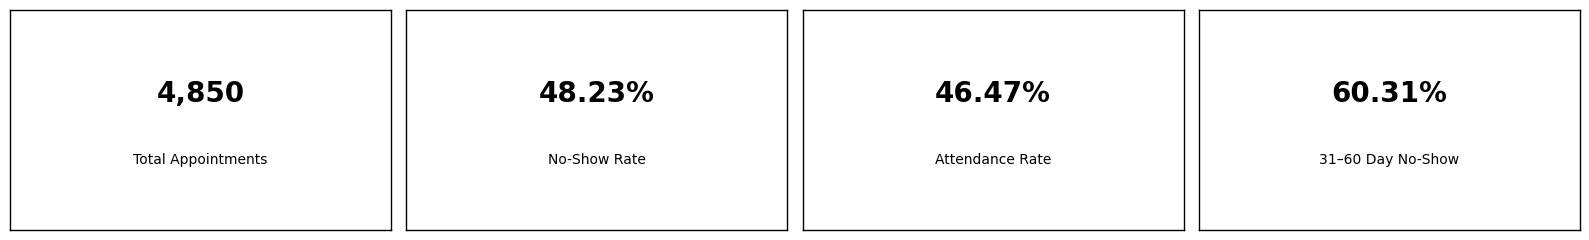

In [82]:
# Create KPI visual
fig, axes = plt.subplots(1, 4, figsize=(16, 2.5))

kpis = [
    (f"{total_appointments:,}", "Total Appointments"),
    (f"{no_show_rate:.2f}%", "No-Show Rate"),
    (f"{attendance_rate:.2f}%", "Attendance Rate"),
    (f"{long_lead_no_show_rate:.2f}%", "31–60 Day No-Show")
]

for ax, (value, title) in zip(axes, kpis):

    ax.text(
        0.5, 0.62,
        value,
        ha='center',
        va='center',
        fontsize=20,
        fontweight='bold'
    )

    ax.text(
        0.5, 0.32,
        title,
        ha='center',
        va='center',
        fontsize=10
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1)

plt.tight_layout()
plt.show()

## CONTEXT

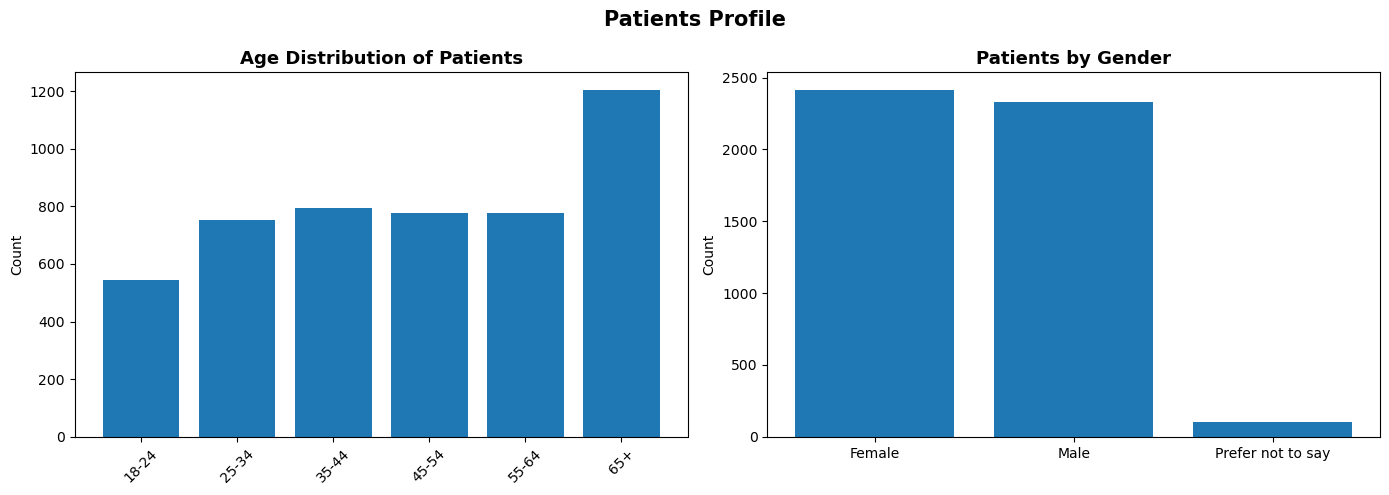

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_counts = df["age_group"].value_counts().sort_index()

axes[0].bar(age_counts.index, age_counts.values)
axes[0].set_title("Age Distribution of Patients", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

gender_counts = df["gender"].value_counts()

axes[1].bar(
    gender_counts.index,
    gender_counts.values
)
axes[1].set_title("Patients by Gender", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Count")

plt.suptitle(
    "Patients Profile",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Chart 1 — Context

The dataset contains 4,850 appointment records. The 65+ age group had the largest number of appointments with 1,205 records, while the 18–24 group had the fewest with 546. Female and Male appointments were relatively similar in number.

This provides context on the patient profile before examining appointment outcomes.

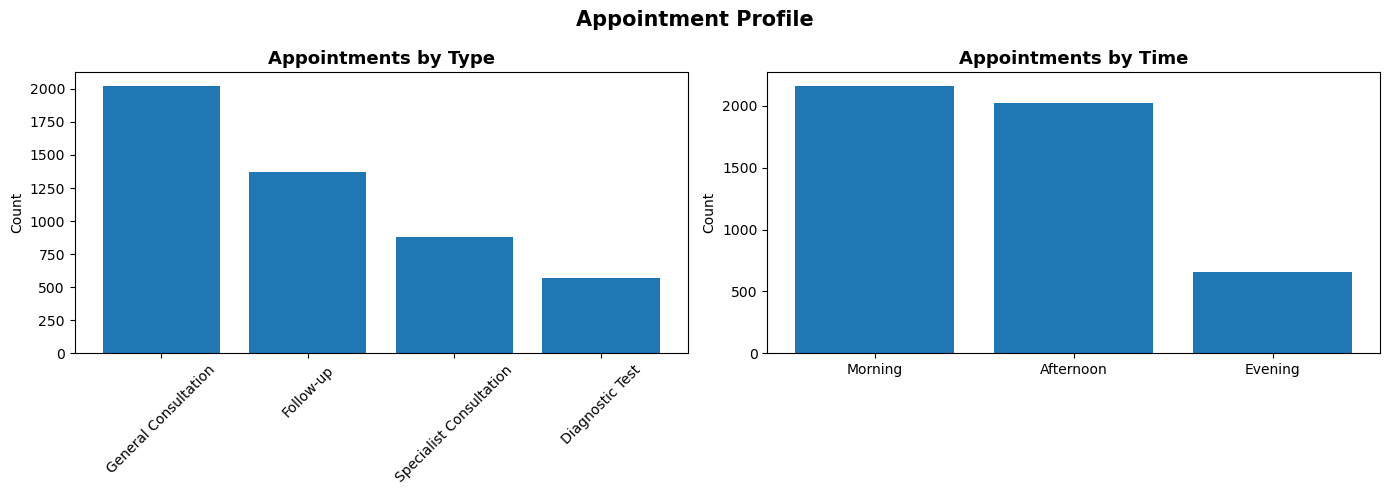

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

appointment_type_counts = df["appointment_type"].value_counts()

axes[0].bar(
    appointment_type_counts.index,
    appointment_type_counts.values
)
axes[0].set_title("Appointments by Type", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

appointment_time_counts = df["appointment_time"].value_counts()

axes[1].bar(
    appointment_time_counts.index,
    appointment_time_counts.values
)
axes[1].set_title("Appointments by Time", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Count")

plt.suptitle(
    "Appointment Profile",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### Chart 2 — Context

General Consultation had the largest number of appointments with 2,024 records, while Diagnostic Test had the fewest with 571. Morning and Afternoon appointments accounted for most of the appointment activity, with 2,164 and 2,026 records respectively.

This shows how appointment activity was distributed before examining no-show patterns.

## Outcome

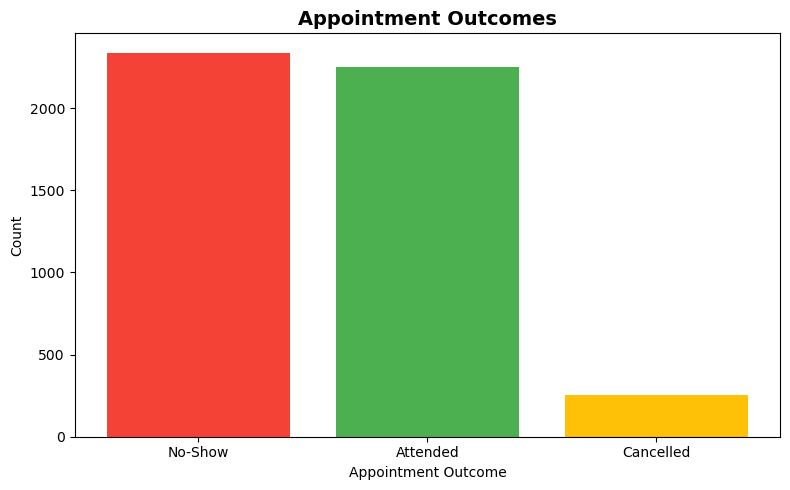

In [85]:
outcome_counts = df["appointment_outcome"].value_counts()

outcome_colors = {
    "Attended": "#4CAF50",
    "No-Show": "#F44336",
    "Cancelled": "#FFC107"
}

plt.figure(figsize=(8, 5))

plt.bar(
    outcome_counts.index,
    outcome_counts.values,
    color=[outcome_colors[outcome] for outcome in outcome_counts.index]
)

plt.title("Appointment Outcomes", fontsize=14, fontweight="bold")
plt.xlabel("Appointment Outcome")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Chart 3 — Outcome

No-Show was the most common appointment outcome at 2,339 records, followed by Attended with 2,254 records. There were 257 cancelled appointments.

This establishes no-shows as the main outcome explored in the analysis that follows.

## Main Finding

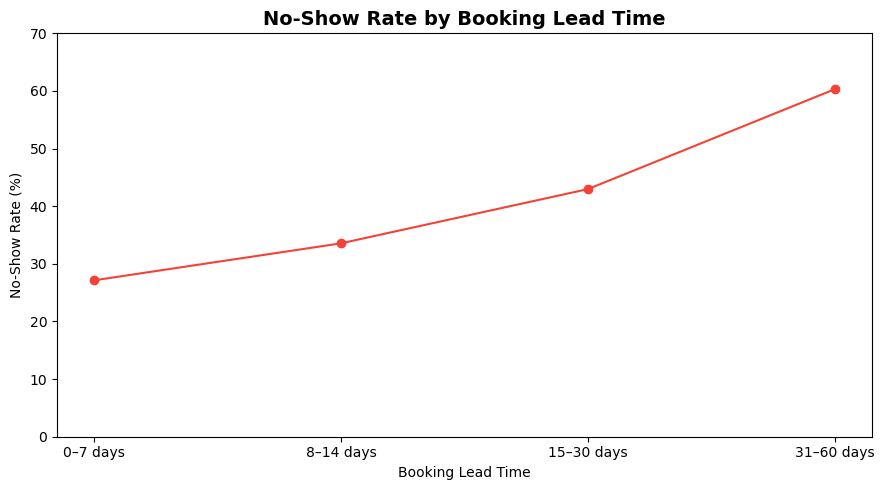

In [86]:
lead_time_outcome = pd.crosstab(
    df["lead_time_group"],
    df["appointment_outcome"],
    normalize="index"
).mul(100).round(2)

plt.figure(figsize=(9, 5))

plt.plot(
    lead_time_outcome.index,
    lead_time_outcome["No-Show"],
    marker="o",
    color="#F44336"
)

plt.title(
        "No-Show Rate by Booking Lead Time",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Booking Lead Time")
plt.ylabel("No-Show Rate (%)")
plt.ylim(0, 70)

plt.tight_layout()
plt.show()

Chart 4 — Main Finding

No-show rates varied across the factors examined, but booking lead time showed the clearest difference. The no-show rate increased from 27.14% for appointments booked 0–7 days in advance to 60.31% for appointments booked 31–60 days in advance.

The 33.17 percentage-point gap indicates a substantial observed association between longer booking lead times and no-shows. This made booking lead time the main pattern selected for deeper investigation.

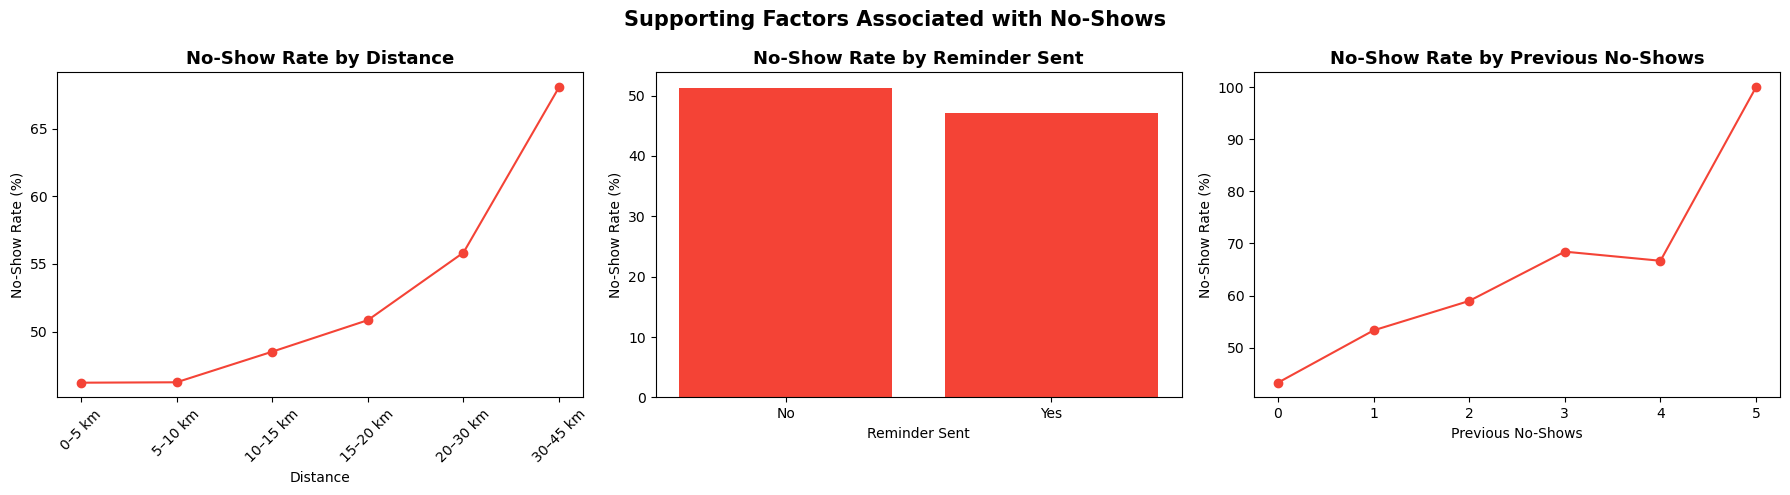

In [87]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distance to clinic
distance_outcome = pd.crosstab(
    df["distance_band"],
    df["appointment_outcome"],
    normalize="index"
).mul(100).round(2)

axes[0].plot(
    distance_outcome.index,
    distance_outcome["No-Show"],
    marker="o",
    color="#F44336"
)
axes[0].set_title("No-Show Rate by Distance", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Distance")
axes[0].set_ylabel("No-Show Rate (%)")
axes[0].tick_params(axis="x", rotation=45)

# Reminder sent
reminder_outcome = pd.crosstab(
    df["reminder_sent"],
    df["appointment_outcome"],
    normalize="index"
).mul(100).round(2)

axes[1].bar(
    reminder_outcome.index,
    reminder_outcome["No-Show"],
    color="#F44336"
)
axes[1].set_title(
    "No-Show Rate by Reminder Sent",
    fontsize=13,
    fontweight="bold"
)
axes[1].set_xlabel("Reminder Sent")
axes[1].set_ylabel("No-Show Rate (%)")

# Previous no-shows
previous_noshow_outcome = pd.crosstab(
    df["previous_no_shows"],
    df["appointment_outcome"],
    normalize="index"
).mul(100).round(2)

axes[2].plot(
    previous_noshow_outcome.index,
    previous_noshow_outcome["No-Show"],
    marker="o",
    color="#F44336"
)
axes[2].set_title(
    "No-Show Rate by Previous No-Shows",
    fontsize=13,
    fontweight="bold"
)
axes[2].set_xlabel("Previous No-Shows")
axes[2].set_ylabel("No-Show Rate (%)")

plt.suptitle(
    "Supporting Factors Associated with No-Shows",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## Chart 5 — Supporting Findings

Other factors also showed patterns in no-show rates, although the differences were generally smaller than the booking lead-time pattern. Distance from the clinic showed increasing no-show rates across longer distances, while previous no-show history was also associated with higher no-show rates. Reminder activity showed a smaller difference between appointments with and without a reminder.

These findings provide additional context but do not show a pattern as consistent or substantial as booking lead time.

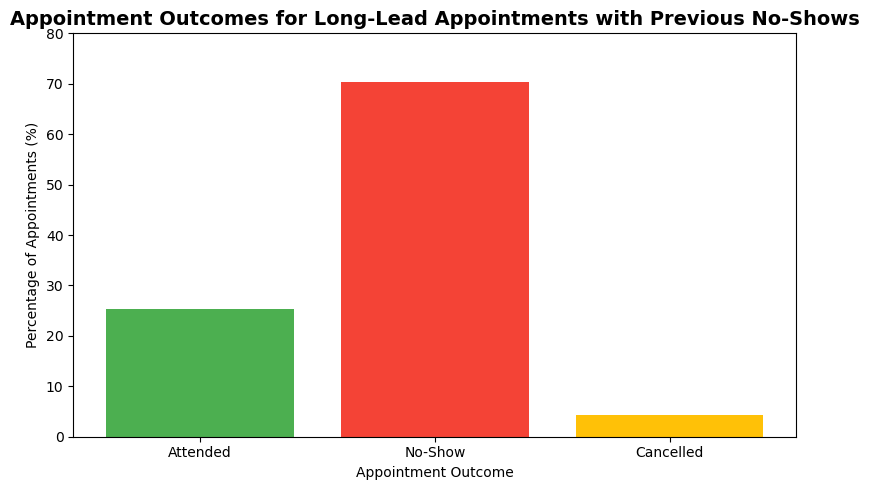

In [88]:
subgroup_outcome = (
    high_risk_group["appointment_outcome"]
    .value_counts(normalize=True)
    .mul(100)
    .reindex(["Attended", "No-Show", "Cancelled"])
)

outcome_colors = {
    "Attended": "#4CAF50",
    "No-Show": "#F44336",
    "Cancelled": "#FFC107"
}

plt.figure(figsize=(8, 5))

plt.bar(
    subgroup_outcome.index,
    subgroup_outcome.values,
    color=[outcome_colors[outcome] for outcome in subgroup_outcome.index]
)

plt.title(
    "Appointment Outcomes for Long-Lead Appointments with Previous No-Shows",
    fontsize=14,
    fontweight="bold"
)
plt.xlabel("Appointment Outcome")
plt.ylabel("Percentage of Appointments (%)")

plt.ylim(0, 80)

plt.tight_layout()
plt.show()

## Cause, Effect, Business Impact and Recommendations
### Gap / Finding

Booking lead time showed the clearest difference in no-show rates among the factors examined. Appointments booked 31–60 days in advance had a no-show rate of 60.31% (1,419 no-shows out of 2,353 appointments), compared with 27.14% (168 no-shows out of 619 appointments) for appointments booked 0–7 days in advance.

This represents a 33.17 percentage-point difference and indicates a substantial observed association between longer booking lead times and no-shows.

Supporting analysis also identified higher no-show rates among patients with previous no-shows and generally higher rates across longer distance bands.

### Cause

A possible reason for the higher no-show rate among longer-lead appointments is that patients may forget their appointment when there is a longer period between booking and the appointment. Patients' circumstances or plans may also change during this period.

Previous no-show history may indicate ongoing attendance barriers, while longer travel distances may create additional access or transport challenges.

The dataset does not prove these are the causes of non-attendance. Further investigation could examine reminder timing, confirmation responses, recorded reasons for missed appointments, transport or access information, and patient communication history.

### Effect

If these patterns continue, a substantial number of appointment slots may go unused. Of the 2,353 appointments booked 31–60 days in advance, 1,419 were no-shows, representing 60.31% of appointments in this group.

Patients with previous no-shows also showed higher subsequent no-show rates. For example, patients with two previous no-shows had a 58.96% overall no-show rate, compared with 43.27% among patients with no previous no-shows.

### Business Impact

High levels of non-attendance can reduce effective clinic capacity and make appointment scheduling less predictable. Repeated missed appointments may also require additional administrative follow-up and reduce the availability of appointment slots for other patients.

The findings suggest that booking lead time and previous no-show history could be useful factors for identifying appointments that may require additional attendance support.

### Recommendations

Based on the analysis, HealthConnect could consider:

Targeted follow-up: Review appointments booked 31–60 days in advance and consider confirmation or reminder follow-ups closer to the appointment date.
Previous no-show history: Consider additional follow-up for patients with previous no-shows, particularly those with two or more previous no-shows.
Distance and access: Review whether patients travelling longer distances experience access or transport barriers and whether alternative options may be appropriate.
Reminder process: Continue using appointment reminders while reviewing reminder timing and confirmation responses to determine whether the process could be improved.
Further data collection: Record reasons for missed appointments and other relevant operational information so potential causes of non-attendance can be tested rather than assumed.

In [89]:
df.to_csv("HealthConnect_Cleaned.csv", index=False)

## SQL Analysis

The following screenshots show the results of the SQL queries completed on the HealthConnect dataset.

### Query 1 — Appointment Outcomes

This query groups appointments by appointment outcome and counts the number of records in each outcome category. This shows the distribution of attended, cancelled, and no-show appointments.

![SQL Query 1](SQL_Query_1.png)

### Interpretation

No-shows were the most common outcome, with 2,339 of the 4,850 appointments missed, compared with 2,254 attended appointments and 257 cancelled appointments.

### Query 2 — No-Show Count by Appointment Type

This query uses CASE WHEN and SUM() to count the number of no-show appointments for each appointment type. This allows the no-show count to be compared across appointment types.

![SQL Query 2](SQL_Query_2.png)

### Interpretation:
General Consultations had the highest number of no-shows, with 939, followed by Follow-up appointments with 702, Specialist Consultations with 417, and Diagnostic Tests with 281.

### Query 3 — Overall No-Show Rate

This query uses a Common Table Expression (CTE) to calculate the total number of appointments and the number of no-show appointments, and then uses these values to calculate the overall no-show rate.

![SQL Query 3](SQL_Query_3.png)

### Interpretation: 
The overall no-show rate was 48.23%, meaning that almost half of the 4,850 appointments were not attended.

https://github.com/Hajarat-A/HealthConnect-Data-Quality-Appointment-Analysis.git?utm_source=chatgpt.com